# NLP RAG for Psychiatric Symptoms

- loads 5 documents, saves as embeddings in chromaDB (good for clinical embeddings - pubmedBERT and industry standard, supports up to 512 tokens)
- uses Mistral, LlaMa and GEMMA
- evaluates using BLEU/ROUGE + BERT (precision, recall, F1) + Precision@K, Recall@K



# Set-Up and Mounting

In [ ]:
#mounting google drive for sources

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

# Path to the zip folder
zip_path = "/content/Sources.zip"
# Directory where you want to extract the files
extract_path = "/s"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
  #libraries for RAG implementation (langchain, chromaDB, langchain-text-splitters, langchain-community)
!pip install -U langchain langchain-community langchain-text-splitters langchain-chroma langchain-huggingface langchain-classic \
                chromadb sentence-transformers pymupdf bitsandbytes accelerate huggingface_hub evaluate rouge_score sacrebleu

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.5 MB/s eta 0:00:00
   ━━━━━━

In [ ]:

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from huggingface_hub import login
from google.colab import userdata
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline, AutoConfig
from langchain_huggingface import HuggingFacePipeline
from langchain_classic.chains import RetrievalQA
import pandas as pd
import seaborn as sns
import evaluate
import matplotlib.pyplot as plt
import re
import os
from langchain_core.prompts import PromptTemplate
import gc




### Ingesting Source Documents using LangChain PDF (Doesn't need to be run again once saved to cloud storage)

- knowledge base is built from five authoritative psychiatric documents including the DSM-5-TR (gold standard), APA treatment guidelines, and the WHO mhGAP programme
- Documents are chunked into 1,000-token segments with a 100-token overlap using LangChain's RecursiveCharacterTextSplitter

In [ ]:


#file paths on google drive
file_paths = [
    "/s/sources/DSM 5 TR.pdf", #DSM 5 full book
    "/s/sources/apa_treatment_depression.pdf", #APA guide treating depression
    "/s/sources/fundamentals_of_psych_disorders.pdf", #open source textbook on psych disorders
    "/s/sources/personality_disorders_dsm.pdf", #dsm guide to personality disorders
    "/s/sources/who_mental_health_gap.pdf" #WHO mental health treatment
]

docs = []
for path in file_paths: #loading loop
    loader = PyMuPDFLoader(path)
    docs.extend(loader.load())

#chunking into chunks of 1000
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = text_splitter.split_documents(docs)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Saving as Embeddings in ChromaDB in Google Drive (Doesn't need to be run again)
- avoids having to re-ingest everytime
- embedded using NeuML/pubmedbert-base-embeddings - which is a domain-specific BERT model pretrained on PubMed abstracts

In [ ]:

persist_directory = '/content/drive/My Drive/NLP RAG Project/embeddings/psychiatry_vector_db' #saving to gdrive so we don't have to keep loading the 5 docs

#embeddings
embeddings = HuggingFaceEmbeddings(
    model_name="NeuML/pubmedbert-base-embeddings", #PubmedBERT (bioBERT)
    model_kwargs={'device': 'cpu'}
)

#creating and saving (only needs to be run once)
vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=persist_directory
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#hugging face authentification


#secret token from hugging face
hf_token = userdata.get('HF_TOKEN')

if hf_token:
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
else:
    print("HF_TOKEN not found in Colab Secrets.")

Successfully logged in to Hugging Face!


# RAG Implementation
- Mistral
- LLama
- Gemma

## MISTRAL (doesn't need to be run again after saving)

- All three models are loaded under 4-bit NF4 quantization using BitsAndBytes with double quantization enabled (compute dtype float16 instead of float32). This reduces VRAM requirements substantially while preserving generation quality for inference.
- All three models also use a prompt template to make the output more helpful for this specific task.
- Each model is wrapped in a LangChain RetrievalQA chain using the 'stuff' strategy. This means that retrieved chunks are concatenated directly into the prompt context. The prompt template instructs the model to cite source filenames and terminate with a SOURCES USED: section, which feeds into our retrieval evaluation and helps with transparency which is particularly important for psychiatric domains.



In [ ]:


#getting mistral model
model_id = "mistralai/Mistral-7B-Instruct-v0.3" #mistral

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, #4 bit quantizing for storage
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

#loading tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

#RAG pipeline
#including mistral stop tokens
terminators = [tokenizer.eos_token_id, tokenizer.convert_tokens_to_ids("<|eot_id|>")]

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    eos_token_id=terminators,
    pad_token_id=tokenizer.eos_token_id,
    temperature=0.1 #keeping this low to prioritize accuracry
)

llm = HuggingFacePipeline(pipeline=pipe)

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#saving model to google drive


save_directory = "/content/drive/My Drive/NLP RAG Project/models/Mistral-7B-4bit"
os.makedirs(save_directory, exist_ok=True)

#save model and tokenizer
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

NameError: name 'model' is not defined

## Loading Embeddings and MISTRAL Model (load from here)

In [ ]:
persist_directory = '/content/drive/My Drive/NLP RAG Project/embeddings/psychiatry_vector_db' #directory containing saved vectorized data

embeddings = HuggingFaceEmbeddings(
    model_name="NeuML/pubmedbert-base-embeddings", #PubmedBERT (bioBERT)
    model_kwargs={'device': 'cpu'}
)
vector_db = Chroma(
    persist_directory=persist_directory,
    embedding_function=embeddings
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_17220/546319122.py:7: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_db = Chroma(


In [ ]:
print(vector_db)

In [ ]:
#Loading mistral from drive

save_directory = "/content/drive/My Drive/NLP RAG Project/models/Mistral-7B-4bit"


#config (4 bit)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
save_directory,
quantization_config=bnb_config,
device_map="auto",
local_files_only=True
)
tokenizer = AutoTokenizer.from_pretrained(save_directory)


/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
import os

path = "/content/drive/My Drive/NLP RAG Project/models/Mistral-7B-4bit"

print("Directory exists:", os.path.exists(path))
print("Files found:")
for f in os.listdir(path):
    print(" -", f)

Directory exists: False
Files found:


FileNotFoundError: [Errno 2] No such file or directory: '/drive/My Drive/NLP RAG Project/models/Mistral-7B-4bit'

### Loading Questions
 1.⁠ ⁠What are the core diagnostic criteria for Major Depressive Disorder, and how many symptoms are required for a formal diagnosis?

2.⁠ ⁠How does Persistent Depressive Disorder differ from Major Depressive Disorder in terms of symptom duration and severity?

3.⁠ ⁠What key features distinguish Generalized Anxiety Disorder from Panic Disorder?

4.⁠ ⁠What are the essential impairments required for diagnosing a personality disorder?

5.⁠ ⁠A patient reports persistent sadness, fatigue, and sleep disturbances lasting over two years. What is the most likely diagnosis, and what criteria support this conclusion?

6.⁠ ⁠How can clinicians differentiate between depressive episodes in bipolar disorder and those in unipolar depression?

7.⁠ ⁠A patient demonstrates impulsivity, lack of empathy, and manipulative behavior. What diagnosis should be considered, and what characteristics support it?

8.⁠ ⁠What are the most effective psychological treatments for depression across different age groups?

9.⁠ ⁠How do psychotherapy and pharmacological treatments compare in effectiveness for treating depressive disorders?

10.⁠ ⁠What treatment strategies are recommended for managing depression in low-resource or non-specialized healthcare settings?

11.⁠ ⁠How should treatment plans be individualized based on patient-specific factors such as culture, comorbidities, and personal preferences?

12.⁠ ⁠How do diagnostic frameworks and treatment guidelines work together in clinical decision-making for psychiatric disorders?

13.⁠ ⁠What are the limitations of symptom-based diagnostic approaches in psychiatry?

14.⁠ ⁠How does comorbidity affect the accuracy of diagnosis and the effectiveness of treatment planning?

15.⁠ ⁠Given a patient presenting with overlapping symptoms of anxiety and depression, how should a clinician determine the primary diagnosis and appropriate treatment approach?

16.⁠ ⁠What challenges arise in accurately diagnosing psychiatric disorders, and how can clinicians address these challenges?

17.⁠ ⁠How can AI-based systems assist in improving access to psychiatric diagnosis and treatment recommendations?

In [ ]:
questions = [
    "What are the core diagnostic criteria for Major Depressive Disorder, and how many symptoms are required for a formal diagnosis?",
    "How does Persistent Depressive Disorder differ from Major Depressive Disorder in terms of symptom duration and severity?",
    "What key features distinguish Generalized Anxiety Disorder from Panic Disorder?",
    "What are the essential impairments required for diagnosing a personality disorder?",
    "A patient reports persistent sadness, fatigue, and sleep disturbances lasting over two years. What is the most likely diagnosis, and what criteria support this conclusion?",
    "How can clinicians differentiate between depressive episodes in bipolar disorder and those in unipolar depression?",
    "A patient demonstrates impulsivity, lack of empathy, and manipulative behavior. What diagnosis should be considered, and what characteristics support it?",
    "What are the most effective psychological treatments for depression across different age groups?",
    "How do psychotherapy and pharmacological treatments compare in effectiveness for treating depressive disorders?",
    "What treatment strategies are recommended for managing depression in low-resource or non-specialized healthcare settings?",
    "How should treatment plans be individualized based on patient-specific factors such as culture, comorbidities, and personal preferences?",
    "How do diagnostic frameworks and treatment guidelines work together in clinical decision-making for psychiatric disorders?",
    "What are the limitations of symptom-based diagnostic approaches in psychiatry?",
    "How does comorbidity affect the accuracy of diagnosis and the effectiveness of treatment planning?",
    "Given a patient presenting with overlapping symptoms of anxiety and depression, how should a clinician determine the primary diagnosis and appropriate treatment approach?",
    "What challenges arise in accurately diagnosing psychiatric disorders, and how can clinicians address these challenges?",
    "How can AI-based systems assist in improving access to psychiatric diagnosis and treatment recommendations?"
]

firfddeee### Testing MISTRAL performance on 1 Question

In [ ]:
#huggingface pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)

llm = HuggingFacePipeline(pipeline=pipe)

#RAG and embedding link
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_db.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True
)

#test question 1
query = "What are three key distinctions between major depressive disorder and generalized anxiety disorder?"

#run query
result = qa_chain.invoke(query)

#print answer
print("MISTRAL RESPONSE:")
print(result["result"])

print("Sources:")
for doc in result["source_documents"]:
    print(f"Source: {doc.metadata.get('source', 'Unknown')}")
    print(f"Excerpt: {doc.page_content[:200]}...\n")

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MISTRAL RESPONSE:
Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

Fundamentals of Psychological Disorders
103
Identify and describe the two types of depressive disorders.
Classify symptoms of depression.
Describe premenstrual dysphoric disorder.
 
4.1.1. Distinguishing Mood Disorders
Within mood disorders are two distinct groups—individuals with depressive disorders and individuals
with bipolar disorders. The key difference between the two mood disorder groups is episodes of
mania/hypomania. More specifically, in bipolar I disorder, the individual experiences a manic episode
that “may have been preceded by and may be followed by hypomanic or major depressive episodes”
(APA, 2022, pg. 139) whereas for bipolar II disorder, the individual has experienced in the past or is
currently experiencing a hypomanic episode and has experienced in the past or is currently
experiencing 

### Prompt Template for all 3 models.

In [ ]:
#code to provide clean output rather than long mistral output


template = """Use the following pieces of context to answer the question at the end.
For each piece of context, the source filename is provided.
When you answer, try to mention which document the information came from.
At the very end of your answer, provide a section labeled 'SOURCES USED:' and list the filenames.

Context:
{context}

Question: {question}

Helpful Answer:"""

QA_CHAIN_PROMPT = PromptTemplate(
    input_variables=["context", "question"],
    template=template,
)

In [ ]:
#loop to test all 17 questions at once

import pandas as pd
import re
import os

#huggingface pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)

llm = HuggingFacePipeline(pipeline=pipe)

#RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_db.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
)



evaluation_data = []

for i, query in enumerate(questions):
    result = qa_chain.invoke(query)
    full_output = result["result"]

    #splitting helpful answer sections and sources sections for storage df
    if "Helpful Answer:" in full_output:
        useful_text = full_output.split("Helpful Answer:")[-1].strip()
    else:
        useful_text = full_output.strip()

    #using regexp
    split_pattern = r"(?i)sources\s*used:|sources:"

    parts = re.split(split_pattern, useful_text)

    if len(parts) > 1:
        final_answer = parts[0].strip()
        mistral_sources = parts[1].strip()
    else:
        final_answer = useful_text
        mistral_sources = "No sources cited by model"

    reference_text = " ".join([doc.page_content for doc in result["source_documents"]])

    evaluation_data.append({
        "Question": query,
        "Mistral Answer": final_answer,
        "Mistral Sources": mistral_sources,
        "Retrieved Reference": reference_text
    })

df_results = pd.DataFrame(evaluation_data)
display(df_results.head())



NameError: name 'model' is not defined

In [ ]:
#save to gdrive for report
df_results.to_csv("/content/drive/My Drive/NLP RAG Project/Mistral_Evaluation_Results.csv", index=True)

### BLEU/ROUGE Evaluatoin
- BLEU and ROUGE-L were computed against the retrieved reference chunks to see how different and similar the returned answers were to the actual context they were retrieved from
- The key finding is the consistent gap between ROUGE and BLEU across all three models.
- This pattern is actually good: it indicates the models are successfully recalling the correct clinical concepts and ideas, but expressing them in natural language rather than reproducing source text (which is not necessarily useful)

In [ ]:
#!pip install evaluate rouge_score sacrebleu

#bleu and rouge metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

#metrics for each row
def compute_metrics(row):
    #BLEU
    b = bleu.compute(predictions=[row["Mistral Answer"]],
                     references=[row["Retrieved Reference"]])
    #ROUGE
    r = rouge.compute(predictions=[row["Mistral Answer"]],
                     references=[row["Retrieved Reference"]])

    return pd.Series([round(b['bleu'], 4), round(r['rougeL'], 4)])

#add to DF
df_results[['BLEU', 'ROUGE-L']] = df_results.apply(compute_metrics, axis=1)



In [ ]:
df_results = pd.read_csv("/content/drive/My Drive/NLP RAG Project/Mistral_Evaluation_Results.csv")

In [ ]:
#Sort by Rouge to see most accurate
display(df_results.sort_values(by="ROUGE-L", ascending=False))

,Question,Mistral Answer,Mistral Sources,Retrieved Reference,BLEU,ROUGE-L
15,What challenges arise in accurately diagnosing...,Accurately diagnosing psychiatric disorders ca...,APA. (2022). Diagnostic and Statistical Manual...,not show all symptoms indicative of a diagnosi...,0.3792,0.5136
10,How should treatment plans be individualized b...,Treatment plans should be individualized based...,1. individualizing_treatment.txt\n2. treatment...,literature about treatments as well as limitat...,0.1956,0.4969
7,What are the most effective psychological trea...,The most effective psychological treatments fo...,- depression_treatment.txt,depression in general (i.e. not specific to de...,0.1291,0.3902
13,How does comorbidity affect the accuracy of di...,"Comorbidity, or the presence of multiple menta...",1. depression_and_treatment_recommendations.tx...,"As noted earlier, depression is frequently fou...",0.0891,0.3889
3,What are the essential impairments required fo...,"To diagnose a personality disorder, there must...",1. personality_disorders.txt\n2. personality_d...,"personality disorder, the following criteria m...",0.0633,0.3415
12,What are the limitations of symptom-based diag...,The limitations of symptom-based diagnostic ap...,1. abnormal_psychology.txt\n2. psychopathology...,1.\nlimitations?\nCan we adequately define nor...,0.0322,0.3223
14,Given a patient presenting with overlapping sy...,To determine the primary diagnosis and appropr...,1. elements_of_a_diagnosis.txt\n2. diagnostic_...,individual’s signs and symptoms and their cont...,0.1181,0.2645
8,How do psychotherapy and pharmacological treat...,Psychotherapy and pharmacological treatments h...,1. mood_disorders.txt,Discuss the effectiveness of the different pha...,0.0111,0.2613
9,What treatment strategies are recommended for ...,In low-resource or non-specialized healthcare ...,1. depression_management_in_low_resource_setti...,clotting (e.g. non-steroidal anti-inflammatory...,0.0052,0.2415
16,How can AI-based systems assist in improving a...,AI-based systems can assist in improving acces...,1. brief_interventions_in_primary_care.txt\n2....,increase detection of substance use disorders ...,0.0182,0.2375


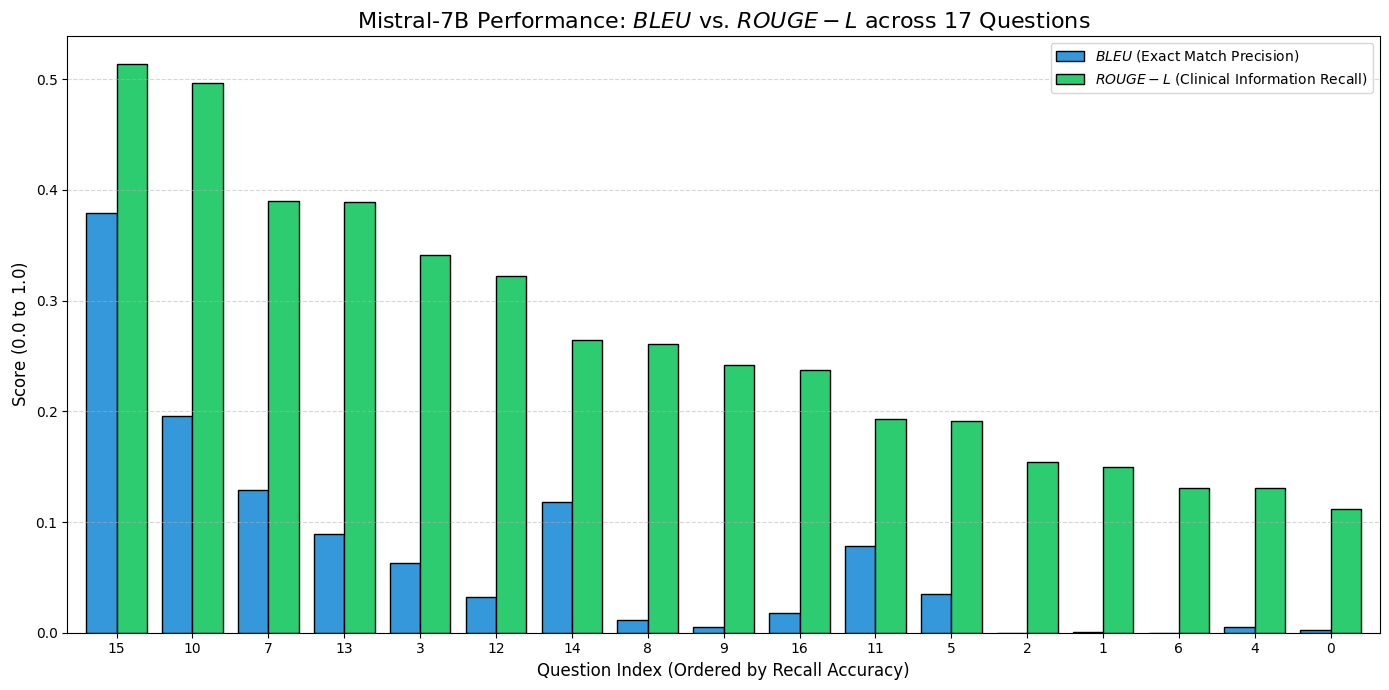

In [ ]:


#sorting by rouge
df_sorted = df_results.sort_values(by='ROUGE-L', ascending=False)

#grouped bar chart
ax = df_sorted.plot(
    kind='bar',
    y=['BLEU', 'ROUGE-L'],
    figsize=(14, 7),
    color=['#3498db', '#2ecc71'],  #blue for BLEU, green for ROUGE
    edgecolor='black',
    width=0.8
)

plt.title('Mistral-7B Performance: $BLEU$ vs. $ROUGE-L$ across 17 Questions', fontsize=16)
plt.xlabel('Question Index (Ordered by Recall Accuracy)', fontsize=12)
plt.ylabel('Score ($0.0$ to $1.0$)', fontsize=12)
plt.legend(["$BLEU$ (Exact Match Precision)", "$ROUGE-L$ (Clinical Information Recall)"])

#Formatting
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

#save plot
plt.savefig('/content/drive/My Drive/NLP RAG Project/mistral_evaluation_bar_chart.png')

### Interpretation

- if ROUGE is high, but BLEU is low, it suggests that the RAG is is capturing psychiatric facts, but not using the same terminology as the reference material

- if ROUGE and BLEU are both high, it suggests that the RAG is capturing both psychiatric facts, and also closely matching the exact phrasing used in the reference material


In [ ]:
print("Question 15: ", df_results.Question[15])
print("Answer 15: ", df_results["Mistral Answer"][15])
print("Reference 15: ", df_results["Retrieved Reference"][15])


Question 15:  What challenges arise in accurately diagnosing psychiatric disorders, and how can clinicians address these challenges?
Answer 15:  Accurately diagnosing psychiatric disorders can be challenging due to several factors. First, symptoms that are indicative of a diagnosis should not be used to limit access to appropriate care (APA, 2022). This means that not all symptoms should be considered when making a diagnosis.

Second, symptoms that cluster together regularly are called a syndrome, and if they follow a predictable course, they are characteristic of a specific disorder. However, the classification systems used by mental health professionals to make diagnoses are based on distinct disorders with clear descriptions and criteria. People suffering from delusions, hallucinations, disorganized thinking, grossly disorganized or abnormal motor behavior, and/or negative symptoms are different from those presenting with a primary clinical deficit in cognitive functioning that is n

- looking at question 15 (with the highest ROUGE and BLEU score) we can see that this answered the question very well, listing 5 highly relevant reasons for diagnosis challenges and referencing appropriate material (APA guidelines)

In [ ]:
print("Question 0: ", df_results.Question[0])
print("Question 0: ", df_results["Mistral Answer"][0])
print("Reference 0: ", df_results["Retrieved Reference"][0])



Question 0:  What are the core diagnostic criteria for Major Depressive Disorder, and how many symptoms are required for a formal diagnosis?
Question 0:  The core diagnostic criteria for Major Depressive Disorder, as outlined in the DSM-5-TR, include at least five of the following symptoms: depressed mood, loss of interest or pleasure, significant weight loss or gain, insomnia or hypersomnia, psychomotor agitation or retardation, fatigue or loss of energy, feelings of worthlessness or excessive or inappropriate guilt, diminished ability to think or concentrate, or recurrent thoughts of death or suicide. For a formal diagnosis, at least five of these symptoms must be present nearly every day for a period of at least two weeks.
Reference 0:  episode are present but full criteria are not met, or there is a period lasting less
than 2 months without any significant symptoms of a major depressive episode
following the end of such an episode.
In full remission: During the past 2 months, no si

- for question 0, the RAG did not perform well in terms of retrieving relevant documents and addressing severity, leading to a low ROUGE score, even though the question is actually answered.
- Just in not much detail, with no mention about severity. But this is a medically accurate answer. Meeting at least 5 symptoms for a period of two weeks.  

In [ ]:
print("Question 3: ", df_results.Question[3])
print("Question 3: ", df_results["Mistral Answer"][3])
print("Reference 3: ", df_results["Retrieved Reference"][3])


Question 3:  What are the essential impairments required for diagnosing a personality disorder?
Question 3:  To diagnose a personality disorder, there must be significant impairments in personality functioning,
which can be seen in either impairments in self functioning or impairments in interpersonal functioning.
Within self functioning, the impairments can be in identity or in self-direction. Identity impairments
occur when an individual's sense of self is derived predominantly from work or productivity, and
their experience and expression of personality is constricted.
Reference 3:  personality disorder, the following criteria must be met: 
 
A. Significant impairments in personality functioning manifest by: 
1. Impairments in self functioning (a or b): 
a. Identity: Sense of self derived predominantly from work or 
productivity; constricted experience and expression of personality disorder, the following criteria must be met: 
 
A. Significant impairments in personality functioning

- question 3 shows high ROUGE but low BLUE performance, indicating that the answer is clinically accurate, but uses very different language from the reference material to explain the answer

### Human Evaluation (Relevance + Accuracy)

In [ ]:

file_name = '/content/drive/My Drive/Mistral_Evaluation_Results_Relevance.xlsx'

df_human_eval = pd.read_excel(file_name)
df_results = df_results.merge(
    df_human_eval[['Question', 'Reference Relevance', 'Clinical Accuracy']],
    on='Question',
    how='left'
)

display(df_results.head())


,Question,Mistral Answer,Mistral Sources,Retrieved Reference,Reference Relevance,Clinical Accuracy
0,What are the core diagnostic criteria for Majo...,The core diagnostic criteria for Major Depress...,1. DSM-5: Diagnostic and Statistical Manual of...,episode are present but full criteria are not ...,1,2
1,How does Persistent Depressive Disorder differ...,"Persistent Depressive Disorder, unlike Major D...",1. persistent_depressive_disorder.txt\n2. majo...,The perceived abnormality or tolerance of chro...,2,2
2,What key features distinguish Generalized Anxi...,Generalized Anxiety Disorder (GAD) and Panic D...,- APA_2022.pdf,"symptoms, with some panic attacks presenting w...",2,2
3,What are the essential impairments required fo...,"To diagnose a personality disorder, significan...",1. personality_disorder_criteria.txt\n2. perso...,"personality disorder, the following criteria m...",2,2
4,"A patient reports persistent sadness, fatigue,...",The most likely diagnosis for this patient is ...,1. major_depressive_disorder.txt\n2. depressio...,either subjective account or observation by ot...,2,2


In [ ]:
print("Mean Reference Relevance =", df_results['Reference Relevance'].mean()) #out of 2
print("Mean Clinical Accuracy =", df_results['Clinical Accuracy'].mean()) #out of 2

Mean Reference Relevance = 1.3529411764705883
Mean Clinical Accuracy = 2.0


In [ ]:
file_name = '/content/drive/My Drive/Mistral_Evaluation_Results_Relevance.xlsx'
df_human_eval = pd.read_excel(file_name)

print("Mean BLEU Mistral =", df_human_eval['BLEU'].mean())
print("SD BLEU Mistral =", df_human_eval['BLEU'].std())

print("Mean ROUGE Mistral =", df_human_eval['ROUGE-L'].mean())
print("SD ROUGE Mistral =", df_human_eval['ROUGE-L'].std())


Mean BLEU Mistral = 0.08500588235294117
SD BLEU Mistral = 0.10582000325191497
Mean ROUGE Mistral = 0.24438823529411766
SD ROUGE Mistral = 0.12654491733349538


- Mean BLEU Mistral = 0.0850 (sd = 0.106)
- Mean ROUGE Mistral = 0.244 (sd = 0.127)

- Mean reference relevance is 1.35/2
- But answers are clinically accurate - there were no glaring errors/misinformation given

# LLAMA

- this needs to be run once then can be loaded from google drive after saving.

In [ ]:

#del model
#del tokenizer
gc.collect()
torch.cuda.empty_cache() #clearing mistral memory

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

#specific to llama
terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    eos_token_id=terminators,
    pad_token_id=tokenizer.eos_token_id,
    temperature=0.1, #low for accuracy
    do_sample=True,
)

llm = HuggingFacePipeline(pipeline=pipe)

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 112.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 87.81 MiB is free. Including non-PyTorch memory, this process has 14.47 GiB memory in use. Of the allocated memory 14.29 GiB is allocated by PyTorch, and 53.81 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import torch
import pandas as pd
import re
import os
import evaluate
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
from transformers import HuggingFacePipeline
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

ModuleNotFoundError: No module named 'evaluate'

In [ ]:
save_directory = "/content/drive/My Drive/NLP RAG Project/models/Llama-3.1-8B-4bit"

os.makedirs(save_directory, exist_ok=True)

#save model and tokenizer
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)


NameError: name 'model' is not defined

### Loading LLaMA from drive (run from here)

In [ ]:


save_directory = "/content/drive/My Drive/NLP RAG Project/models/Llama-3.1-8B-4bit"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    save_directory,
    quantization_config=bnb_config,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(save_directory)


ValueError: Unrecognized configuration class <class 'transformers.models.bit.configuration_bit.BitConfig'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm4MoeLiteConfig, GotOcr2Config, GPT2

In [ ]:

template = """Use the following pieces of context to answer the question at the end.
For each piece of context, the source filename is provided.
When you answer, try to mention which document the information came from.
At the very end of your answer, provide a section labeled 'SOURCES USED:' and list the filenames.

Context:
{context}

Question: {question}

Helpful Answer:"""

QA_CHAIN_PROMPT = PromptTemplate(
    input_variables=["context", "question"],
    template=template,
)

In [ ]:
#loop to test all 17 questions at once



#huggingface pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)

llm = HuggingFacePipeline(pipeline=pipe)

#RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_db.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
)



evaluation_data = []

for i, query in enumerate(questions):
    result = qa_chain.invoke(query)
    full_output = result["result"]

    if "Helpful Answer:" in full_output:
        useful_text = full_output.split("Helpful Answer:")[-1].strip()
    else:
        useful_text = full_output.strip()

    split_pattern = r"(?i)sources\s*used:|sources:"

    parts = re.split(split_pattern, useful_text)

    if len(parts) > 1:
        final_answer = parts[0].strip()
        llama_sources = parts[1].strip()
    else:
        final_answer = useful_text
        llama_sources = "No sources cited by model"

    reference_text = " ".join([doc.page_content for doc in result["source_documents"]])

    evaluation_data.append({
        "Question": query,
        "LLaMa Answer": final_answer,
        "LLaMa Sources": llama_sources,
        "Retrieved Reference": reference_text
    })

df_results = pd.DataFrame(evaluation_data)
display(df_results.head())

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformer

,Question,LLaMa Answer,LLaMa Sources,Retrieved Reference
0,What are the core diagnostic criteria for Majo...,The core diagnostic criteria for Major Depress...,DSM-5-TR (Section 3.2 Review Questions)\nDSM-5...,episode are present but full criteria are not ...
1,How does Persistent Depressive Disorder differ...,Persistent Depressive Disorder (PDD) is charac...,1. persistent_depressive_disorder.pdf\n2. pers...,The perceived abnormality or tolerance of chro...
2,What key features distinguish Generalized Anxi...,Panic disorder is characterized by recurrent u...,1. Fundamentals of Psychological Disorders\n2....,"symptoms, with some panic attacks presenting w..."
3,What are the essential impairments required fo...,"According to the DSM-5, the essential impairme...",DSM-5.pdf\nDSM-5.pdf\nDSM-5.pdf\nDSM-5.pdf\nDS...,"personality disorder, the following criteria m..."
4,"A patient reports persistent sadness, fatigue,...",The most likely diagnosis is Persistent Depres...,1. apa_2022.txt\n2. apa_2022.txt\n3. apa_2022....,either subjective account or observation by ot...


In [ ]:
df_results.to_csv("/content/drive/My Drive/NLP RAG Project/LLAMA_Evaluation_Results.csv", index=True)

In [ ]:
#!pip install evaluate rouge_score sacrebleu


#bleu and rouge metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

#metrics for each row
def compute_metrics(row):
    #BLEU
    b = bleu.compute(predictions=[row["LLaMa Answer"]],
                     references=[row["Retrieved Reference"]])
    #ROUGE
    r = rouge.compute(predictions=[row["LLaMa Answer"]],
                     references=[row["Retrieved Reference"]])

    return pd.Series([round(b['bleu'], 4), round(r['rougeL'], 4)])

#add to DF
df_results[['BLEU', 'ROUGE-L']] = df_results.apply(compute_metrics, axis=1)

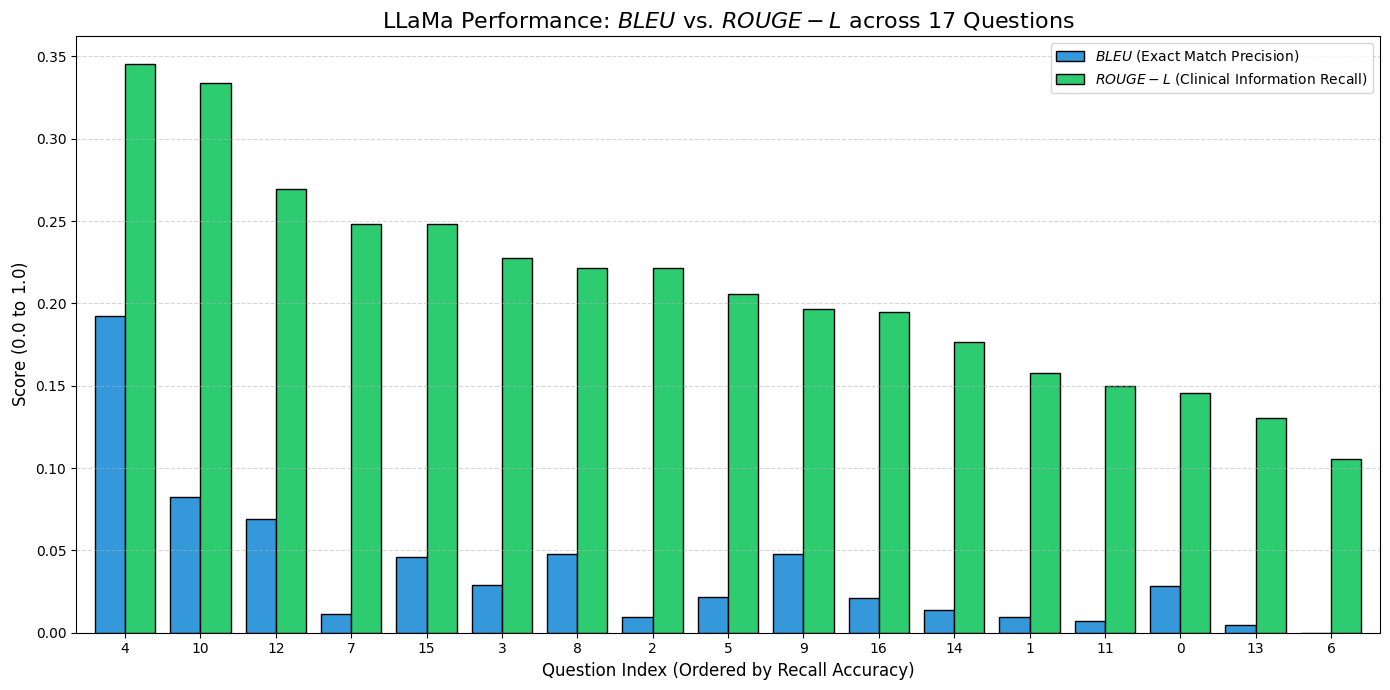

In [ ]:


#sorting by rouge
df_sorted = df_results.sort_values(by='ROUGE-L', ascending=False)

#grouped bar chart
ax = df_sorted.plot(
    kind='bar',
    y=['BLEU', 'ROUGE-L'],
    figsize=(14, 7),
    color=['#3498db', '#2ecc71'],  #blue for BLEU, green for ROUGE
    edgecolor='black',
    width=0.8
)

plt.title('LLaMa Performance: $BLEU$ vs. $ROUGE-L$ across 17 Questions', fontsize=16)
plt.xlabel('Question Index (Ordered by Recall Accuracy)', fontsize=12)
plt.ylabel('Score ($0.0$ to $1.0$)', fontsize=12)
plt.legend(["$BLEU$ (Exact Match Precision)", "$ROUGE-L$ (Clinical Information Recall)"])

#Formatting
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

#save plot
plt.savefig('/content/drive/My Drive/NLP RAG Project/llama_evaluation_bar_chart.png')

In [ ]:
print("Question 4: ", df_results.Question[4])
print("Question 4: ", df_results["LLaMa Answer"][4])
print("Reference 4: ", df_results["Retrieved Reference"][4])


Question 4:  A patient reports persistent sadness, fatigue, and sleep disturbances lasting over two years. What is the most likely diagnosis, and what criteria support this conclusion?
Question 4:  The most likely diagnosis is Persistent Depressive Disorder (PDD), as the patient reports symptoms of depressed mood, fatigue, and sleep disturbances lasting over two years. The criteria supporting this conclusion include:

*   The patient's symptoms of depressed mood, fatigue, and sleep disturbances lasting over two years meet the diagnostic criteria for PDD, which requires a depressed mood for most of the day, for more days than not, for at least two years (APA, 2022).
*   The patient's symptoms also include two or more additional symptoms, such as changes in appetite, low energy or fatigue, low self-esteem, feelings of hopelessness, and poor concentration or difficulty with decision making, which are also required for a diagnosis of PDD (APA, 2022).
Reference 4:  either subjective account

- question with the highest ROUGE score was question 4 - about likely diagnosis of PDD


In [ ]:
print("Question 6: ", df_results.Question[6])
print("Question 6: ", df_results["LLaMa Answer"][6])
print("Reference 6: ", df_results["Retrieved Reference"][6])

Question 6:  A patient demonstrates impulsivity, lack of empathy, and manipulative behavior. What diagnosis should be considered, and what characteristics support it?
Question 6:  The diagnosis that should be considered is Antisocial Personality Disorder (301.7). The characteristics that support this diagnosis include impulsivity (Criterion 1), lack of empathy (Criterion 2), and manipulative behavior (Criterion 3). These behaviors are often seen in individuals with Antisocial Personality Disorder, who tend to disregard the rights of others, engage in deceitful behavior, and exhibit a lack of concern for the feelings or rights of others.
Reference 6:  schizophrenia, personality disorder). This category may be used only when the problem is
sufficiently severe to warrant independent clinical attention and does not meet diagnostic criteria
for psychological factors affecting other medical conditions.
E66.9
Overweight or Obesity
This category may be used when overweight or obesity is a focu

- question with lowest BLEU score was 6 - about diagnosing someone with symptoms of ASPD - language used is completely different from the reference text
- but ROUGE was still okay (around 0.10).  

In [ ]:
#loading LLAMA human evaluation ratings

file_name = '/content/drive/My Drive/NLP RAG Project/LLAMA_Evaluation_Results_Relevance.xlsx'

df_human_eval = pd.read_excel(file_name)
df_results = df_results.merge(
    df_human_eval[['Question', 'Reference Relevance LLaMa', 'Clinical Accuracy LLaMa']],
    on='Question',
    how='left'
)

display(df_results.head())

NameError: name 'df_results' is not defined

In [ ]:
print("Mean Reference Relevance =", df_results['Reference Relevance LLaMa'].mean()) #out of 2
print("Mean Clinical Accuracy =", df_results['Clinical Accuracy LLaMa'].mean()) #out of 2

Mean Reference Relevance = 1.5294117647058822
Mean Clinical Accuracy = 2.0


- More relevant resources referenced (1.529)
- Still as accurate - there was nothing incorrect about the responses.

In [ ]:
print("Mean BLEU LLaMa =", df_results['BLEU'].mean())
print("SD BLEU LLaMa =", df_results['BLEU'].std())

print("Mean ROUGE LLaMa =", df_results['ROUGE-L'].mean())
print("SD ROUGE LLaMa =", df_results['ROUGE-L'].std())

Mean BLEU LLaMa = 0.03781176470588235
SD BLEU LLaMa = 0.046177482098325555
Mean ROUGE LLaMa = 0.2105529411764706
SD ROUGE LLaMa = 0.06617290908716968


- Mean BLEU LLaMa = 0.0301 (sd = 0.0371)
- Mean ROUGE LLaMa = 0.212 (sd = 0.0791)
- Which is worse performance in terms of BLEU and ROUGE compared to Mistral.

# Gemma
- One implementation note worth noting different from LLamA and Mistral: Gemma requires a custom prompt wrapper using its <start_of_turn> / <end_of_turn> chat template and it does not follow the same instruction format as Mistral or LLaMA

In [ ]:
import gc
import torch

to_delete = ['model', 'tokenizer', 'pipe', 'llm', 'qa_chain']

for obj in to_delete:
    if obj in locals():
        del locals()[obj]

gc.collect()
torch.cuda.empty_cache()
print(f"VRAM currently in use: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

VRAM currently in use: 0.00 GB


In [ ]:

model_id = "google/gemma-2-9b-it"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16
)


terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<end_of_turn>")
]

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    eos_token_id=terminators,
    pad_token_id=tokenizer.eos_token_id,
    temperature=0.1,
    do_sample=True,
)

llm = HuggingFacePipeline(pipeline=pipe)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'eos_token_id', 'max_new_tokens', 'pad_token_id', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
#saving
model.save_pretrained("/content/drive/My Drive/NLP RAG Project/models/Gemma-2-9b-4bit")
tokenizer.save_pretrained("/content/drive/My Drive/NLP RAG Project/models/Gemma-2-9b-4bit")

In [ ]:
template = """Use the following pieces of context to answer the question at the end.
For each piece of context, the source filename is provided.
When you answer, try to mention which document the information came from.
At the very end of your answer, provide a section labeled 'SOURCES USED:' and list the filenames.

Context:
{context}

Question: {question}

Helpful Answer:"""


#specific text wrapper for gemma, which is an instruct model.
gemma_template = f"""<start_of_turn>user
{template}<end_of_turn>
<start_of_turn>model
"""


QA_CHAIN_PROMPT = PromptTemplate(
    input_variables=["context", "question"],
    template=gemma_template,
)

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_db.as_retriever(search_kwargs={"k": 3}),
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT},
    return_source_documents=True
)

In [ ]:
evaluation_data = []

for i, query in enumerate(questions):
    result = qa_chain.invoke(query)
    full_output = result["result"]

    if "Helpful Answer:" in full_output:
        useful_text = full_output.split("Helpful Answer:")[-1].strip()
    else:
        useful_text = full_output.strip()

    split_pattern = r"(?i)sources\s*(?:used)?\s*:"

    parts = re.split(split_pattern, useful_text)

    if len(parts) > 1:
        final_answer = parts[0].strip()
        gemma_sources = parts[1].strip()
    else:
        final_answer = useful_text
        gemma_sources = "No sources cited by model"

    reference_text = " ".join([doc.page_content for doc in result["source_documents"]])

    evaluation_data.append({
        "Question": query,
        "GEMMA Answer": final_answer,
        "GEMMA Sources": gemma_sources,
        "Retrieved Reference": reference_text
    })

df_results = pd.DataFrame(evaluation_data)
display(df_results.head())

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

,Question,GEMMA Answer,GEMMA Sources,Retrieved Reference
0,What are the core diagnostic criteria for Majo...,<end_of_turn>\n<start_of_turn>model\nThe provi...,**\n\n* dsm-5-tr.txt,episode are present but full criteria are not ...
1,How does Persistent Depressive Disorder differ...,<end_of_turn>\n<start_of_turn>model\nPersisten...,"- ""Persistent Depressive Disorder""",The perceived abnormality or tolerance of chro...
2,What key features distinguish Generalized Anxi...,<end_of_turn>\n<start_of_turn>model\nGeneraliz...,Fundamentals of Psychological Disorders,"symptoms, with some panic attacks presenting w..."
3,What are the essential impairments required fo...,<end_of_turn>\n<start_of_turn>model\nTo be dia...,- personality_disorder_criteria.txt,"personality disorder, the following criteria m..."
4,"A patient reports persistent sadness, fatigue,...",<end_of_turn>\n<start_of_turn>model\nThe most ...,"APA, 2022",either subjective account or observation by ot...


In [ ]:
df_results.to_csv("/content/drive/My Drive/NLP RAG Project/GEMMA_Evaluation_Results.csv", index=True)

In [ ]:
#bleu and rouge metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

#metrics for each row
def compute_metrics(row):
    #BLEU
    b = bleu.compute(predictions=[row["GEMMA Answer"]],
                     references=[row["Retrieved Reference"]])
    #ROUGE
    r = rouge.compute(predictions=[row["GEMMA Answer"]],
                     references=[row["Retrieved Reference"]])

    return pd.Series([round(b['bleu'], 4), round(r['rougeL'], 4)])

#add to DF
df_results[['BLEU', 'ROUGE-L']] = df_results.apply(compute_metrics, axis=1)

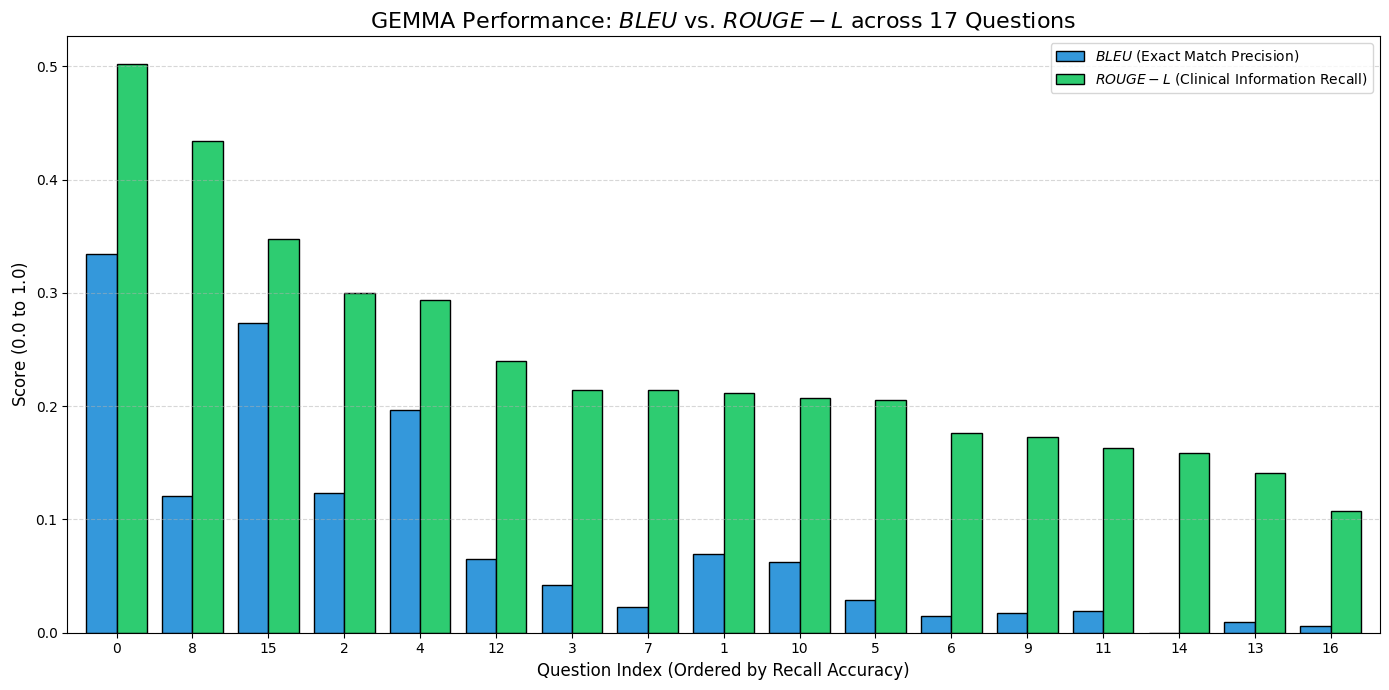

In [ ]:

#sorting by rouge
df_sorted = df_results.sort_values(by='ROUGE-L', ascending=False)

#grouped bar chart
ax = df_sorted.plot(
    kind='bar',
    y=['BLEU', 'ROUGE-L'],
    figsize=(14, 7),
    color=['#3498db', '#2ecc71'],  #blue for BLEU, green for ROUGE
    edgecolor='black',
    width=0.8
)

plt.title('GEMMA Performance: $BLEU$ vs. $ROUGE-L$ across 17 Questions', fontsize=16)
plt.xlabel('Question Index (Ordered by Recall Accuracy)', fontsize=12)
plt.ylabel('Score ($0.0$ to $1.0$)', fontsize=12)
plt.legend(["$BLEU$ (Exact Match Precision)", "$ROUGE-L$ (Clinical Information Recall)"])

#Formatting
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

#save plot
plt.savefig('/content/drive/My Drive/NLP RAG Project/GEMMA_evaluation_bar_chart.png')

In [ ]:
#loading GEMMA human evaluation ratings

file_name = '/content/drive/My Drive/NLP RAG Project/GEMMA_Evaluation_Results_Relevance.xlsx'

df_human_eval = pd.read_excel(file_name)
df_results = df_results.merge(
    df_human_eval[['Question', 'Reference Relevance GEMMA', 'Clinical Accuracy GEMMA']],
    on='Question',
    how='left'
)

display(df_results.head())

,Question,GEMMA Answer,GEMMA Sources,Retrieved Reference,BLEU,ROUGE-L,Reference Relevance GEMMA,Clinical Accuracy GEMMA
0,What are the core diagnostic criteria for Majo...,<end_of_turn>\n<start_of_turn>model\nThe provi...,**\n\n* dsm-5-tr.txt,episode are present but full criteria are not ...,0.3345,0.5018,2,2
1,How does Persistent Depressive Disorder differ...,<end_of_turn>\n<start_of_turn>model\nPersisten...,"- ""Persistent Depressive Disorder""",The perceived abnormality or tolerance of chro...,0.0693,0.2117,2,2
2,What key features distinguish Generalized Anxi...,<end_of_turn>\n<start_of_turn>model\nGeneraliz...,Fundamentals of Psychological Disorders,"symptoms, with some panic attacks presenting w...",0.1235,0.2998,2,2
3,What are the essential impairments required fo...,<end_of_turn>\n<start_of_turn>model\nTo be dia...,- personality_disorder_criteria.txt,"personality disorder, the following criteria m...",0.0423,0.2145,2,2
4,"A patient reports persistent sadness, fatigue,...",<end_of_turn>\n<start_of_turn>model\nThe most ...,"APA, 2022",either subjective account or observation by ot...,0.1964,0.2933,2,2


In [ ]:
print("Mean Reference Relevance =", df_results['Reference Relevance GEMMA'].mean()) #out of 2
print("Mean Clinical Accuracy =", df_results['Clinical Accuracy GEMMA'].mean()) #out of 2

Mean Reference Relevance = 1.588235294117647
Mean Clinical Accuracy = 1.9411764705882353


In [ ]:
print("Mean BLEU GEMMA =", df_results['BLEU'].mean())
print("SD BLEU GEMMA =", df_results['BLEU'].std())

print("Mean ROUGE GEMMA =", df_results['ROUGE-L'].mean())
print("SD ROUGE GEMMA =", df_results['ROUGE-L'].std())

Mean BLEU GEMMA = 0.08275882352941177
SD BLEU GEMMA = 0.09869109672878
Mean ROUGE GEMMA = 0.24053529411764707
SD ROUGE GEMMA = 0.10525454824600497


- better performance than LLaMa in terms of BLEU and GEMMA

### Plot Comparing BLEU and ROUGE across the 3 models

- Mean BLEU GEMMA = 0.08275882352941177
- SD BLEU GEMMA = 0.09869109672878
- Mean ROUGE GEMMA = 0.24053529411764707
- SD ROUGE GEMMA = 0.10525454824600497
- Mean BLEU LLaMa = 0.030094117647058827
- SD BLEU LLaMa = 0.03705403943209558
- Mean ROUGE LLaMa = 0.21198235294117646
- SD ROUGE LLaMa = 0.0790629751787627
- Mean BLEU Mistral = 0.08500588235294117
- SD BLEU Mistral = 0.10582000325191497
- Mean ROUGE Mistral = 0.24438823529411766
- SD ROUGE Mistral = 0.12654491733349538



<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_9172/1501071673.py:29: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title('Comparative Analysis of Model Performance: $BLEU$ vs. $ROUGE$\n(Means $\pm$ Standard Deviation)', fontsize=14)


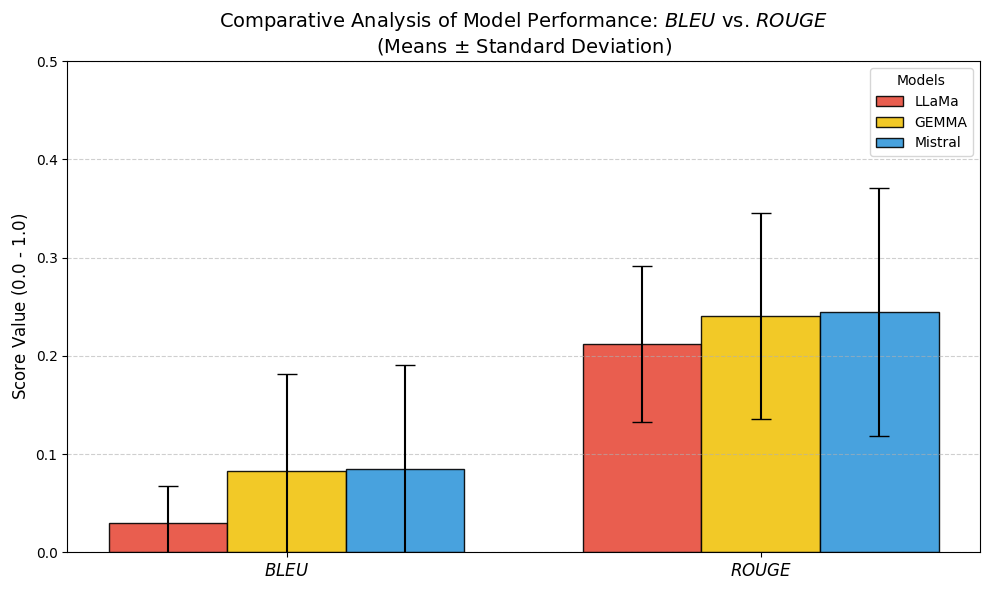

In [ ]:
#manually because i don't want to reload all data
import matplotlib.pyplot as plt
import numpy as np

models = ['LLaMa', 'GEMMA', 'Mistral']
metrics = ['BLEU', 'ROUGE']

means_bleu = [0.0301, 0.0828, 0.0850]
means_rouge = [0.2120, 0.2405, 0.2444]
stds_bleu = [0.0371, 0.0987, 0.1058]
stds_rouge = [0.0791, 0.1053, 0.1265]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#f1c40f', '#3498db'] #Red (LLaMa), Gold (GEMMA), Blue (Mistral)

for i, model in enumerate(models):
    pos = x + (i - 1) * width
    m_vals = [means_bleu[i], means_rouge[i]]
    s_vals = [stds_bleu[i], stds_rouge[i]]

    ax.bar(pos, m_vals, width, yerr=s_vals, label=model,
           color=colors[i], capsize=7, edgecolor='black', alpha=0.9)

ax.set_ylabel('Score Value ($0.0$ - $1.0$)', fontsize=12)
ax.set_title('Comparative Analysis of Model Performance: $BLEU$ vs. $ROUGE$\n(Means $\pm$ Standard Deviation)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['$BLEU$', '$ROUGE$'], fontsize=12)
ax.legend(title='Models', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 0.5)
plt.tight_layout()

plt.savefig('comparative_metrics_plot.png')


- ROUGE being consistently higher suggests that all models are re-weording a lot (not really many exact n matches), but the clinical meaning is being captured decently.

In [ ]:
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_gemma = pd.read_csv('/content/drive/My Drive/NLP RAG Project/GEMMA_Evaluation_Results.csv')
df_llama = pd.read_csv('/content/drive/My Drive/NLP RAG Project/LLAMA_Evaluation_Results.csv')
df_mistral = pd.read_csv('/content/drive/My Drive/NLP RAG Project/Mistral_Evaluation_Results.csv')

df_gemma = df_gemma[['Question', 'BLEU', 'ROUGE-L']].rename(
    columns={'BLEU': 'BLEU_GEMMA', 'ROUGE-L': 'ROUGE_GEMMA'}
)
df_llama = df_llama[['Question', 'BLEU', 'ROUGE-L']].rename(
    columns={'BLEU': 'BLEU_LLAMA', 'ROUGE-L': 'ROUGE_LLAMA'}
)
df_mistral = df_mistral[['Question', 'BLEU', 'ROUGE-L']].rename(
    columns={'BLEU': 'BLEU_Mistral', 'ROUGE-L': 'ROUGE_Mistral'}
)


df_merged = df_llama.merge(df_gemma, on='Question').merge(df_mistral, on='Question')

df_merged.to_csv('All_Models_Merged_Results.csv', index=False)

#One way ANOVA to see if there is any statistical signifiance in difference
f_stat, p_val = stats.f_oneway(
    df_merged['BLEU_LLAMA'],
    df_merged['BLEU_GEMMA'],
    df_merged['BLEU_Mistral']
)

print(f"ANOVA Results for BLEU:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4f}")


ANOVA Results for BLEU:
F-statistic: 1.5668
p-value: 0.2192


- indicates no statistical signifiacne (expected)

Paired T-test for LLaMa (ROUGE vs BLEU):
T-statistic: 17.4442
p-value: 7.78876582e-12


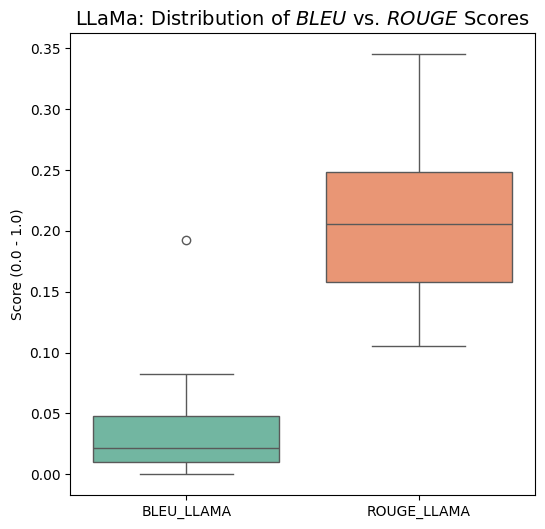

In [ ]:
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#paired ttest for llama to see if Rouge sig > Bleu
t_stat, p_val = stats.ttest_rel(df_llama['ROUGE_LLAMA'], df_llama['BLEU_LLAMA'])

print(f"Paired T-test for LLaMa (ROUGE vs BLEU):")
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.8e}")

plt.figure(figsize=(6, 6))
sns.boxplot(data=df_llama[['BLEU_LLAMA', 'ROUGE_LLAMA']], palette="Set2")
plt.title("LLaMa: Distribution of $BLEU$ vs. $ROUGE$ Scores", fontsize=14)
plt.ylabel("Score (0.0 - 1.0)")
plt.show()

Paired T-test for Mistral (ROUGE vs BLEU):
T-statistic: 8.9708
p-value: 1.21745697e-07


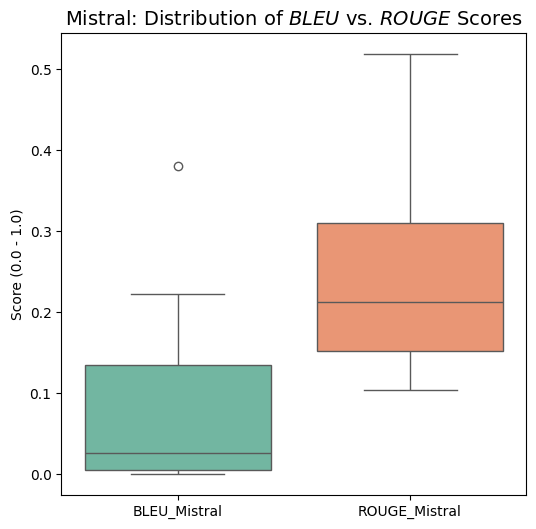

In [ ]:
#paired ttest for mistral to see if Rouge sig > Bleu
t_stat, p_val = stats.ttest_rel(df_mistral['ROUGE_Mistral'], df_mistral['BLEU_Mistral'])

print(f"Paired T-test for Mistral (ROUGE vs BLEU):")
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.8e}")

plt.figure(figsize=(6, 6))
sns.boxplot(data=df_mistral[['BLEU_Mistral', 'ROUGE_Mistral']], palette="Set2")
plt.title("Mistral: Distribution of $BLEU$ vs. $ROUGE$ Scores", fontsize=14)
plt.ylabel("Score (0.0 - 1.0)")
plt.show()

Paired T-test for GEMMA (ROUGE vs BLEU):
T-statistic: 12.7320
p-value: 8.68483291e-10


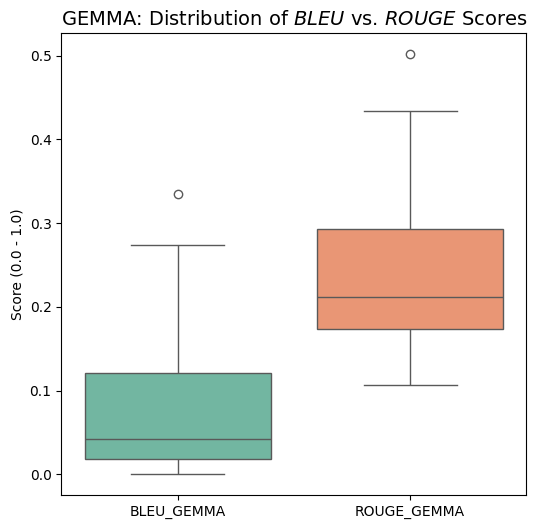

In [ ]:
#paired ttest for mistral to see if Rouge sig > Bleu
t_stat, p_val = stats.ttest_rel(df_gemma['ROUGE_GEMMA'], df_gemma['BLEU_GEMMA'])

print(f"Paired T-test for GEMMA (ROUGE vs BLEU):")
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.8e}")

plt.figure(figsize=(6, 6))
sns.boxplot(data=df_gemma[['BLEU_GEMMA', 'ROUGE_GEMMA']], palette="Set2")
plt.title("GEMMA: Distribution of $BLEU$ vs. $ROUGE$ Scores", fontsize=14)
plt.ylabel("Score (0.0 - 1.0)")
plt.show()

- for all three models (Mistral, LLAMA, GEMMA), Rouge was significantly greater than Bleu.
- this means that all models are successfully recalling the correct symptoms and clinical features (with ROUGE 0.2-0.25)
- but they are not just regurgitating eveyrhint back in the same format - particularly LLaMa (with BLUE 0.05-0.1).

### Outliers
- questions 0, 4 and 15 show high BLEU for gemma, llama and mistral respectively
- GEMMA Question 0 - What are the core diagnostic criteria for Major Depressive Disorder, and how many symptoms are required for a formal diagnosis?'
- LLAMA Question 4 - What are the essential impairments required for diagnosing a personality disorder?
- Mistral Question 15 - What challenges arise in accurately diagnosing psychiatric disorders, and how can clinicians address these challenges?

In [ ]:
display(questions)

['What are the core diagnostic criteria for Major Depressive Disorder, and how many symptoms are required for a formal diagnosis?',
 'How does Persistent Depressive Disorder differ from Major Depressive Disorder in terms of symptom duration and severity?',
 'What key features distinguish Generalized Anxiety Disorder from Panic Disorder?',
 'What are the essential impairments required for diagnosing a personality disorder?',
 'A patient reports persistent sadness, fatigue, and sleep disturbances lasting over two years. What is the most likely diagnosis, and what criteria support this conclusion?',
 'How can clinicians differentiate between depressive episodes in bipolar disorder and those in unipolar depression?',
 'A patient demonstrates impulsivity, lack of empathy, and manipulative behavior. What diagnosis should be considered, and what characteristics support it?',
 'What are the most effective psychological treatments for depression across different age groups?',
 'How do psychothe

# Mistral Model Deployment - ask any psychiatric question!

In [ ]:



template = """Use the following pieces of context to answer the question at the end.
For each piece of context, the source filename is provided.
When you answer, try to mention which document the information came from.
At the very end of your answer, provide a section labeled 'SOURCES USED:' and list the filenames.

Context:
{context}

Question: {question}

Helpful Answer:"""

QA_CHAIN_PROMPT = PromptTemplate(
    input_variables=["context", "question"],
    template=template,
)

#huggingface pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)

llm = HuggingFacePipeline(pipeline=pipe)

#RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_db.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
)

def ask_mistral(question):
    """
    Takes a question string, queries the Mistral RAG chain,
    and prints the formatted clinical answer and sources.
    """
    if 'qa_chain' not in globals():
        return "Error: qa_chain not found. Please re-run your the initialization cells above."

    print(f"Querying Psychiatric Documents for: '{question}'...\n")

    response = qa_chain.invoke(question)

    full_text = response["result"]

    print("-" * 30)
    print(full_text)
    print("-" * 30)

    return response



Passing `generation_config` together with generation-related arguments=({'do_sample', 'pad_token_id', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
user_query = "A patient has some symptoms of a manic episode (impulsivity, recklessness, lack of sleep, hyperactivity). It started after taking cannabis to cope with losing their job, and has lasted for about three days. They have never had a history of psychiatric disease before. How should this be diagnosed?"
result = ask_mistral(user_query)

Querying Psychiatric Documents for: 'A patient has some symptoms of a manic episode (impulsivity, recklessness, lack of sleep, hyperactivity). It started after taking cannabis to cope with losing their job, and has lasted for about three days. They have never had a history of psychiatric disease before. How should this be diagnosed?'...



Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


------------------------------
Use the following pieces of context to answer the question at the end.
For each piece of context, the source filename is provided.
When you answer, try to mention which document the information came from.
At the very end of your answer, provide a section labeled 'SOURCES USED:' and list the filenames.

Context:
151
5. Distractibility (i.e., attention too easily drawn to unimportant or irrelevant
external stimuli), as reported or observed.
6. Increase in goal-directed activity (either socially, at work or school, or
sexually) or psychomotor agitation.
7. Excessive involvement in activities that have a high potential for painful
consequences (e.g., engaging in unrestrained buying sprees, sexual
indiscretions, or foolish business investments).
C. The episode is associated with an unequivocal change in functioning that is
uncharacteristic of the individual when not symptomatic.
D. The disturbance in mood and the change in functioning are observable by
others.

In [ ]:
user_query = "How many days of treatment should a patient with major depression undergo?"
result = ask_mistral(user_query)

Querying Psychiatric Documents for: 'How many days of treatment should a patient with major depression undergo?'...



Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


------------------------------
Use the following pieces of context to answer the question at the end.
For each piece of context, the source filename is provided.
When you answer, try to mention which document the information came from.
At the very end of your answer, provide a section labeled 'SOURCES USED:' and list the filenames.

Context:
differ from typical usual care depending on the setting or place that 
a treatment is provided. Patients seeking a particular treatment may 
wish to ask questions, not only about a given treatment, but the 
extent to which those providing the treatment have been well trained. 
Within this context, prospective patients seeking treatment for 
depression should ask related questions to be assured that the treat­
ment they believe they will be receiving will be provided in a quality 
fashion. This care would ideally be provided by a qualified mental 
health specialist though the panel acknowledges that accessibility to 
these specialists can be a barri

In [ ]:
def retrieval_precision_recall(qa_chain, questions, ground_truth_chunk_ids, k=3):
    results = []
    for query, relevant_ids in zip(questions, ground_truth_chunk_ids):
        result = qa_chain.invoke(query)
        retrieved_ids = [doc.metadata.get('chunk_id') for doc in result["source_documents"]]

        relevant_retrieved = set(retrieved_ids) & set(relevant_ids)
        precision = len(relevant_retrieved) / len(retrieved_ids) if retrieved_ids else 0
        recall    = len(relevant_retrieved) / len(relevant_ids)  if relevant_ids  else 0

        results.append({"question": query, "precision": precision, "recall": recall})
    return pd.DataFrame(results)

In [ ]:
first_five = chunks[40:55]
print(first_five)

[Document(metadata={'producer': 'calibre 3.48.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.48.0 [https://calibre-ebook.com]', 'creationdate': '2022-03-21T21:09:15+00:00', 'source': '/s/sources/DSM 5 TR.pdf', 'file_path': '/s/sources/DSM 5 TR.pdf', 'total_pages': 1377, 'format': 'PDF 1.4', 'title': 'Diagnostic and Statistical Manual of Mental Disorders : Fifth Edition Text Revision DSM-5-TR™', 'author': 'Unknown', 'subject': '', 'keywords': 'Subjects: MESH: Diagnostic and statistical manual of mental disorders. 5th ed | Mental \u2003Disorders—classification | Mental Disorders—diagnosis', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': "D:20220321210915+00'00'", 'page': 34}, page_content='determining a clinical diagnosis.”). “DSM-5” refers to the entire set of currently approved\ncriteria sets, disorders, other conditions, and content officially published in May 2013. “DSM-5-\nTR” refers to approved text in this current volume. Although the scope of the text revisio

In [ ]:
number =0
for doc in first_five:
  page_content = doc.page_content
  # question
  print("Page Starts here--------------",number)
  print(page_content)
  number+=1

Page Starts here-------------- 0
determining a clinical diagnosis.”). “DSM-5” refers to the entire set of currently approved
criteria sets, disorders, other conditions, and content officially published in May 2013. “DSM-5-
TR” refers to approved text in this current volume. Although the scope of the text revision did
not include conceptual changes to the criteria sets or to other DSM-5 constructs, the need to
make changes in certain diagnostic criteria sets for the purpose of clarification became apparent
in conjunction with the text updates made across the book. Because the conceptual construct of
criteria is unchanged, the criteria sets in DSM-5-TR that had their origins in DSM-5 are still
referred to as “DSM-5-criteria.” The new diagnostic entity prolonged grief disorder is referred to
Page Starts here-------------- 1
as a DSM-5-TR disorder, because of its addition in this volume.
The development of DSM-5-TR was a tremendous team effort. We are especially indebted to
the tireless ef

### Heatmap Comparing Answers Across Models

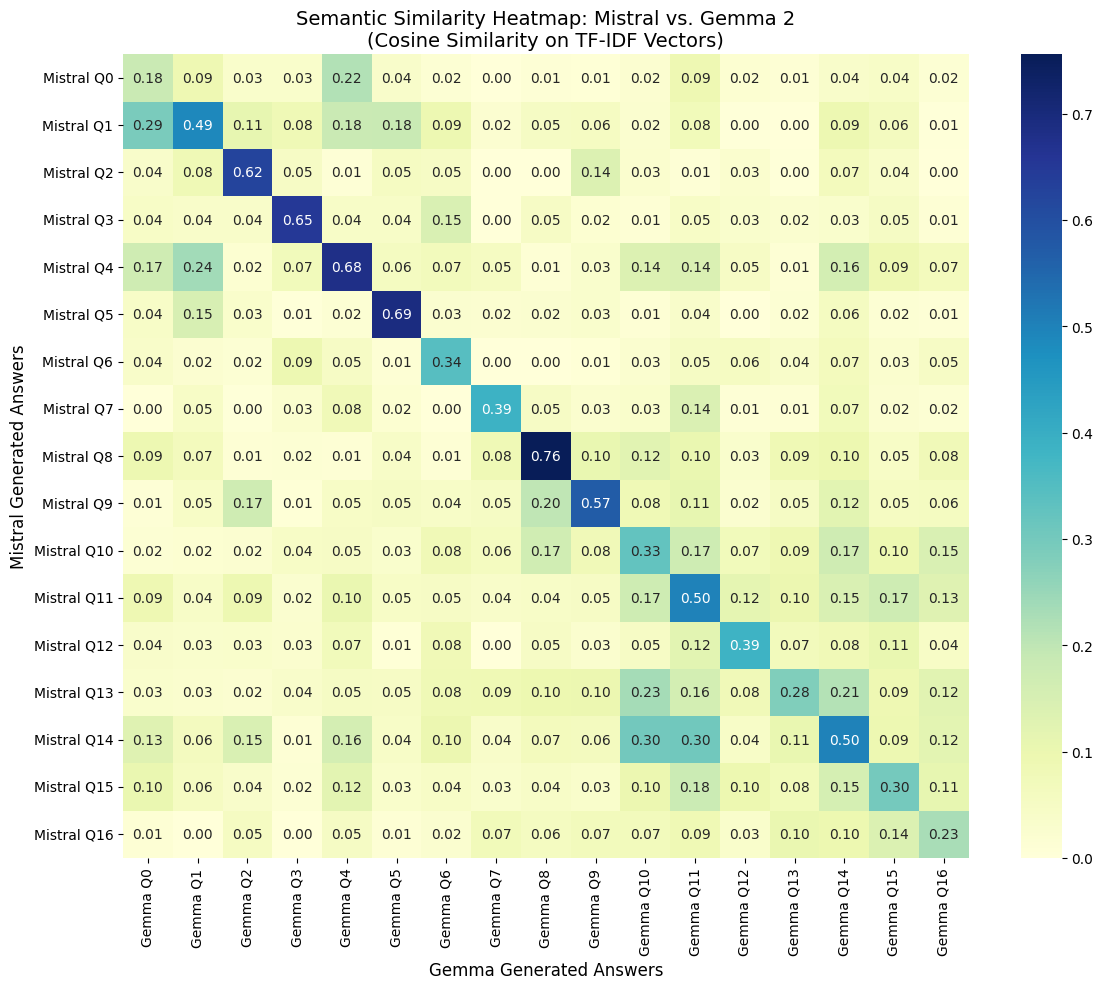

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df_gemma = pd.read_csv('/content/drive/My Drive/NLP RAG Project/GEMMA_Evaluation_Results.csv')
df_mistral = pd.read_csv('/content/drive/My Drive/NLP RAG Project/Mistral_Evaluation_Results.csv')

gemma_answers = df_gemma['GEMMA Answer'].fillna("").tolist()
mistral_answers = df_mistral['Mistral Answer'].fillna("").tolist()

#using tfidf to vectorize
vectorizer = TfidfVectorizer(stop_words='english')
all_answers = gemma_answers + mistral_answers
tfidf_matrix = vectorizer.fit_transform(all_answers)

#cosine similarity between tfidf for each model (gemma vs mistral)
sim_matrix = cosine_similarity(tfidf_matrix[17:], tfidf_matrix[:17])

#heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix,
            annot=True,
            fmt=".2f",
            cmap='YlGnBu',
            xticklabels=[f"Gemma Q{i}" for i in range(17)],
            yticklabels=[f"Mistral Q{i}" for i in range(17)])

plt.title("Semantic Similarity Heatmap: Mistral vs. Gemma 2\n(Cosine Similarity on TF-IDF Vectors)", fontsize=14)
plt.xlabel("Gemma Generated Answers", fontsize=12)
plt.ylabel("Mistral Generated Answers", fontsize=12)
plt.tight_layout()
plt.savefig('model_similarity_heatmap.png')
plt.show()

- It is a good sign that *mostly* the diagonals show the strongest semantic similarity.
- It indicates that the models are generally agreeing (semantically) for the same question.
- the models are especially in alignment for Question 8 (psych vs pharma treatments for depression), Question 5 (differentiation between bipolar and unipolar depression) and Question 4 (patient presenting with sadness, fatigue, sleep issues > 2 years)

In [ ]:

print("---------------------------------")
print("Question 8:", df_gemma.Question[8])

print("GEMMA Answer 8:", df_gemma['GEMMA Answer'][8])
print("-----")
print("Mistral Answer 8:", df_mistral['Mistral Answer'][8])
print("---------------------------------")


print("---------------------------------")
print("Question 5:", df_gemma.Question[5])
print("GEMMA Answer 5:", df_gemma['GEMMA Answer'][5])
print("-----")
print("Mistral Answer 5:", df_mistral['Mistral Answer'][5])
print("---------------------------------")


print("---------------------------------")
print("Question 4:", df_gemma.Question[4])
print("GEMMA Answer 4:", df_gemma['GEMMA Answer'][4])
print("-----")
print("Mistral Answer 4:", df_mistral['Mistral Answer'][4])
print("---------------------------------")


---------------------------------
Question 8: How do psychotherapy and pharmacological treatments compare in effectiveness for treating depressive disorders?
GEMMA Answer 8: <end_of_turn>
<start_of_turn>model
According to the "Module Recap" document, psychological interventions showed higher sustained response than antidepressants over the long term for treating depression.  The document also states that antidepressants have more adverse effects. 

The document goes on to say that combined psychological interventions and antidepressants showed the best results across most analyses.  Combined treatment was better than pharmacotherapy alone in reducing depressive symptoms, treatment response, and remission. These effects were sustained at 6–12 months follow-up, favoring combined treatment.

For individuals with severe depression, combined treatment had a better treatment response compared with pharmacotherapy alone.  There were no differences between psychotherapy alone and pharmacothera

- the answers with the least semantic similarity correspond to questions 0 (MDD Diagnostic Criteria), 16 (AI-based system improvements) and 13 (Comorbidity)
- for questions 16 and 13, the GEMMA model states that there is not enough information from the resources provided, while Mistral still provides an accurate response, one that is potentially hallucinated.

In [ ]:

print("---------------------------------")
print("Question 0:", df_gemma.Question[0])

print("GEMMA Answer 0:", df_gemma['GEMMA Answer'][0])
print("-----")
print("Mistral Answer 0:", df_mistral['Mistral Answer'][0])
print("---------------------------------")


print("---------------------------------")
print("Question 16:", df_gemma.Question[16])
print("GEMMA Answer 16:", df_gemma['GEMMA Answer'][16])
print("-----")
print("Mistral Answer 16:", df_mistral['Mistral Answer'][16])
print("---------------------------------")


print("---------------------------------")
print("Question 13:", df_gemma.Question[13])
print("GEMMA Answer 13:", df_gemma['GEMMA Answer'][13])
print("-----")
print("Mistral Answer 13:", df_mistral['Mistral Answer'][13])
print("---------------------------------")

---------------------------------
Question 0: What are the core diagnostic criteria for Major Depressive Disorder, and how many symptoms are required for a formal diagnosis?
GEMMA Answer 0: <end_of_turn>
<start_of_turn>model
The provided text doesn't explicitly state the core diagnostic criteria for Major Depressive Disorder or the number of symptoms required for a diagnosis. 

It does, however, discuss remission criteria for Major Depressive Disorder:

* **Partial Remission:**  Symptoms of a major depressive episode are present but full criteria are not met, or there is a period lasting less than 2 months without any significant symptoms of a major depressive episode following the end of such an episode.
* **Full Remission:** During the past 2 months, no significant signs or symptoms of the disturbance were present.

The text also outlines severity levels for depressive disorders:

* **Mild:** Few, if any, symptoms in excess of those required to make the diagnosis are present, the int

### Semantic Precision & Recall (BERTScore)

- computes token-level semantic similarity between generated answers and the retrieved reference text
- gets Precision, Recall, and F1 scores.
- Better than BLEU/ROUGE in clinical NLP because it captures semantic equivalence (rewording of same set of symptoms)

In [ ]:
# SEMANTIC PRECISION & RECALL — BERTScore


import pandas as pd
import numpy as np
from bert_score import score as bert_score
import matplotlib.pyplot as plt
import re

df_mistral = pd.read_csv("/content/drive/My Drive/NLP RAG Project/Mistral_Evaluation_Results.csv")
df_llama   = pd.read_csv("/content/drive/My Drive/NLP RAG Project/LLAMA_Evaluation_Results.csv")
df_gemma   = pd.read_csv("/content/drive/My Drive/NLP RAG Project/GEMMA_Evaluation_Results.csv")



In [ ]:

def clean_gemma(text):
    text = re.sub(r"<[^>]+>", "", str(text))   # remove all <...> tags
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_gemma["GEMMA Answer"] = df_gemma["GEMMA Answer"].apply(clean_gemma)



In [ ]:

df_all = df_mistral[["Question", "Mistral Answer", "Retrieved Reference"]].copy()
df_all = df_all.merge(
    df_llama[["Question", "LLaMa Answer"]],
    on="Question", how="left"
)
df_all = df_all.merge(
    df_gemma[["Question", "GEMMA Answer"]],
    on="Question", how="left"
)

#Retrieved Reference is the same across all 3 (same RAG retriever)
#ground-truth reference
references     = df_all["Retrieved Reference"].astype(str).tolist()
mistral_preds  = df_all["Mistral Answer"].astype(str).tolist()
llama_preds    = df_all["LLaMa Answer"].astype(str).tolist()
gemma_preds    = df_all["GEMMA Answer"].astype(str).tolist()

print(f"✅ Loaded {len(df_all)} questions across 3 models")


✅ Loaded 17 questions across 3 models


In [ ]:
MAX_WORDS = 150  # safe range: 100–200

def truncate_text(text):
    return " ".join(str(text).split()[:MAX_WORDS])

mistral_preds = [truncate_text(x) for x in mistral_preds]
llama_preds   = [truncate_text(x) for x in llama_preds]
gemma_preds   = [truncate_text(x) for x in gemma_preds]
references    = [truncate_text(x) for x in references]

In [ ]:
import pandas as pd
import numpy as np
import torch
from bert_score import score as bert_score
import re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

#cleaning text
def clean_text(x):
    x = str(x)
    x = re.sub(r"<[^>]+>", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

#truncating
def truncate_text(x, max_words=120):
    x = clean_text(x)
    return " ".join(x.split()[:max_words])

mistral_preds_clean = [truncate_text(x) for x in mistral_preds]
llama_preds_clean   = [truncate_text(x) for x in llama_preds]
gemma_preds_clean   = [truncate_text(x) for x in gemma_preds]
references_clean    = [truncate_text(x) for x in references]

def compute_bertscore(predictions, references, label):
    print(f"\nScoring {label}...")
    P, R, F1 = bert_score(
        predictions,
        references,
        model_type="roberta-large",
        device=DEVICE,
        verbose=True,
        batch_size=4,
        use_fast_tokenizer=False
    )
    return P.numpy(), R.numpy(), F1.numpy()

mistral_P, mistral_R, mistral_F1 = compute_bertscore(mistral_preds_clean, references_clean, "Mistral")
llama_P,   llama_R,   llama_F1   = compute_bertscore(llama_preds_clean,   references_clean, "LLaMA")
gemma_P,   gemma_R,   gemma_F1   = compute_bertscore(gemma_preds_clean,   references_clean, "Gemma")

Using device: cpu

Scoring Mistral...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/9 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/5 [00:00<?, ?it/s]

done in 43.38 seconds, 0.39 sentences/sec


In [ ]:

df_bertscore = pd.DataFrame({
    "Question":          df_all["Question"],
    "Mistral Precision": mistral_P,
    "Mistral Recall":    mistral_R,
    "Mistral F1":        mistral_F1,
    "LLaMA Precision":   llama_P,
    "LLaMA Recall":      llama_R,
    "LLaMA F1":          llama_F1,
    "Gemma Precision":   gemma_P,
    "Gemma Recall":      gemma_R,
    "Gemma F1":          gemma_F1,
})

display(df_bertscore.round(4))

df_bertscore.to_excel(
    "/content/drive/My Drive/NLP RAG Project/BERTScore_Evaluation.xlsx",
    index=False
)
print("Saved BERTScore_Evaluation.xlsx")

,Question,Mistral Precision,Mistral Recall,Mistral F1,LLaMA Precision,LLaMA Recall,LLaMA F1,Gemma Precision,Gemma Recall,Gemma F1
0,What are the core diagnostic criteria for Majo...,0.8259,0.8323,0.8291,0.8306,0.8446,0.8375,0.8902,0.8925,0.8914
1,How does Persistent Depressive Disorder differ...,0.9078,0.8489,0.8774,0.8584,0.8487,0.8535,0.8427,0.8357,0.8392
2,What key features distinguish Generalized Anxi...,0.9029,0.8337,0.8669,0.8724,0.8174,0.8440,0.8347,0.8189,0.8267
3,What are the essential impairments required fo...,0.8811,0.8413,0.8607,0.8651,0.8333,0.8489,0.8515,0.8254,0.8383
4,"A patient reports persistent sadness, fatigue,...",0.8511,0.8213,0.8360,0.8330,0.8362,0.8346,0.8147,0.8300,0.8223
5,How can clinicians differentiate between depre...,0.8503,0.8601,0.8552,0.8728,0.8550,0.8638,0.8834,0.8598,0.8714
6,"A patient demonstrates impulsivity, lack of em...",0.8395,0.8053,0.8220,0.8318,0.8164,0.8240,0.8389,0.8159,0.8272
7,What are the most effective psychological trea...,0.8658,0.8662,0.8660,0.8986,0.8728,0.8855,0.8914,0.8742,0.8827
8,How do psychotherapy and pharmacological treat...,0.8394,0.8322,0.8357,0.8494,0.8398,0.8446,0.8302,0.8289,0.8296
9,What treatment strategies are recommended for ...,0.8665,0.8316,0.8487,0.8435,0.8301,0.8367,0.8501,0.8304,0.8402


✅ Saved BERTScore_Evaluation.xlsx


### Summary Table of roBERTScore

- shows that mistral was the best-performing model in terms of semantic equivalence between answers and retrieval context

In [ ]:

summary = pd.DataFrame({
    "Model":     ["Mistral", "LLaMA", "Gemma"],
    "Precision": [mistral_P.mean(), llama_P.mean(), gemma_P.mean()],
    "Recall":    [mistral_R.mean(), llama_R.mean(), gemma_R.mean()],
    "F1":        [mistral_F1.mean(), llama_F1.mean(), gemma_F1.mean()],
}).round(4)

print("\n=== BERTScore Summary (mean across 17 questions) ===")
display(summary)


=== BERTScore Summary (mean across 17 questions) ===


,Model,Precision,Recall,F1
0,Mistral,0.8716,0.8490,0.860
1,LLaMA,0.8571,0.8392,0.848
2,Gemma,0.8503,0.8400,0.845


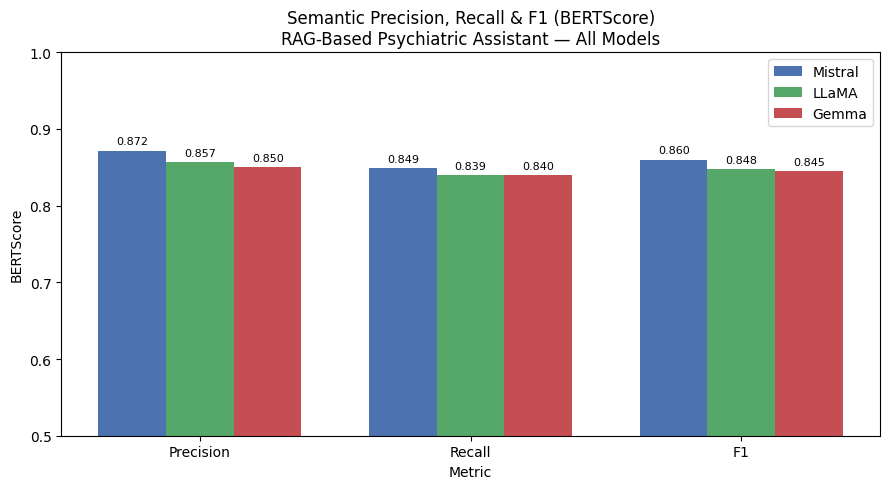

In [ ]:
#bar plot clustered
x      = np.arange(3)
width  = 0.25
labels = ["Precision", "Recall", "F1"]

m_vals = [mistral_P.mean(), mistral_R.mean(), mistral_F1.mean()]
l_vals = [llama_P.mean(),   llama_R.mean(),   llama_F1.mean()]
g_vals = [gemma_P.mean(),   gemma_R.mean(),   gemma_F1.mean()]

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, m_vals, width, label="Mistral", color="#4C72B0")
b2 = ax.bar(x,          l_vals, width, label="LLaMA",  color="#55A868")
b3 = ax.bar(x + width,  g_vals, width, label="Gemma",  color="#C44E52")

ax.set_xlabel("Metric")
ax.set_ylabel("BERTScore")
ax.set_title("Semantic Precision, Recall & F1 (BERTScore)\nRAG-Based Psychiatric Assistant — All Models")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b3, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/My Drive/NLP RAG Project/bertscore_bar_chart.png", dpi=150)
plt.show()


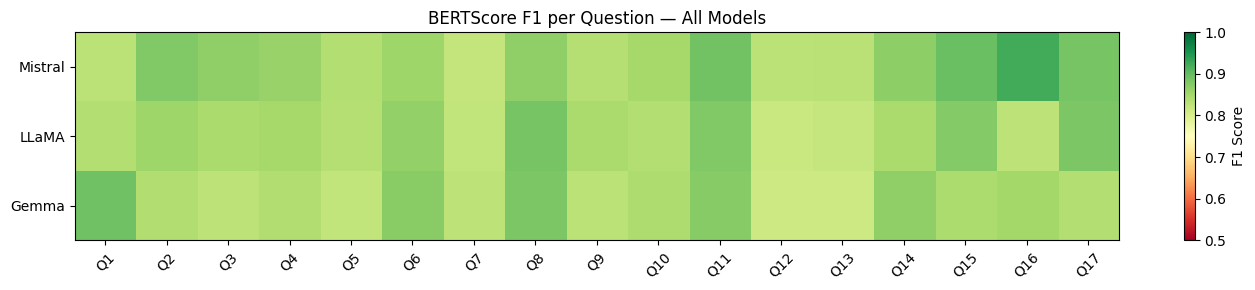

In [ ]:
#f1 per question (heatmap)
q_labels = [f"Q{i+1}" for i in range(len(df_all))]

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(
    np.array([mistral_F1, llama_F1, gemma_F1]),
    aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.0
)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Mistral", "LLaMA", "Gemma"])
ax.set_xticks(range(len(q_labels)))
ax.set_xticklabels(q_labels, rotation=45)
ax.set_title("BERTScore F1 per Question — All Models")
plt.colorbar(im, ax=ax, label="F1 Score")
plt.tight_layout()
plt.savefig("/content/drive/My Drive/NLP RAG Project/bertscore_heatmap.png", dpi=150)
plt.show()

- mistral did the best for Question 16 (index 15):     "What challenges arise in accurately diagnosing psychiatric disorders, and how can clinicians address these challenges?",


### Precision@K and Recall@K (K chunks) and MRR
- did the system retrieve content from the correct document?

In [ ]:
gold_sources = [
    "DSM 5 TR.pdf",                        # 1
    "DSM 5 TR.pdf",                        # 2
    "DSM 5 TR.pdf",                        # 3
    "personality_disorders_dsm.pdf",       # 4
    "DSM 5 TR.pdf",                        # 5
    "DSM 5 TR.pdf",                        # 6
    "personality_disorders_dsm.pdf",       # 7
    "apa_treatment_depression.pdf",        # 8
    "apa_treatment_depression.pdf",        # 9
    "who_mental_health_gap.pdf",           # 10
    "apa_treatment_depression.pdf",        # 11
    "fundamentals_of_psych_disorders.pdf", # 12
    "fundamentals_of_psych_disorders.pdf", # 13
    "fundamentals_of_psych_disorders.pdf", # 14
    "DSM 5 TR.pdf",                        # 15
    "fundamentals_of_psych_disorders.pdf", # 16
    "fundamentals_of_psych_disorders.pdf"  # 17
]

- assigning gold sources from context material based on Questions (mostly DSM 5, except for the question specifically about personality disorders, which refers to a specialised personality disorders pdf)

In [ ]:
import pandas as pd

df_gold = pd.DataFrame({
    "Question": questions,
    "Gold Source": gold_sources
})

display(df_gold)

,Question,Gold Source
0,What are the core diagnostic criteria for Majo...,DSM 5 TR.pdf
1,How does Persistent Depressive Disorder differ...,DSM 5 TR.pdf
2,What key features distinguish Generalized Anxi...,DSM 5 TR.pdf
3,What are the essential impairments required fo...,personality_disorders_dsm.pdf
4,"A patient reports persistent sadness, fatigue,...",DSM 5 TR.pdf
5,How can clinicians differentiate between depre...,DSM 5 TR.pdf
6,"A patient demonstrates impulsivity, lack of em...",personality_disorders_dsm.pdf
7,What are the most effective psychological trea...,apa_treatment_depression.pdf
8,How do psychotherapy and pharmacological treat...,apa_treatment_depression.pdf
9,What treatment strategies are recommended for ...,who_mental_health_gap.pdf


In [ ]:
import numpy as np
import os

def evaluate_retrieval(df_gold, vector_db, k=3):
    precisions = []
    recalls = []

    for _, row in df_gold.iterrows():
        query = row["Question"]
        gold = row["Gold Source"]

        results = vector_db.max_marginal_relevance_search(
            query,
            k=k,
            fetch_k=20
        )

        retrieved_sources = [
            os.path.basename(doc.metadata.get("source", ""))
            for doc in results
        ]

        relevant = sum(1 for s in retrieved_sources if s == gold)

        precision = relevant / k
        recall = 1 if gold in retrieved_sources else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

In [ ]:
for k in [1, 2, 3, 4, 5, 6, 7, 8 , 9, 10, 11, 12, 13, 14, 15, 16, 17]:
    p, r = evaluate_retrieval(df_gold, vector_db, k)
    print(f"k={k}")
    print(f"Precision@{k}: {p:.4f}")
    print(f"Recall@{k}: {r:.4f}\n")

k=1
Precision@1: 0.5294
Recall@1: 0.5294

k=2
Precision@2: 0.4412
Recall@2: 0.5882

k=3
Precision@3: 0.4902
Recall@3: 0.7647

k=4
Precision@4: 0.5000
Recall@4: 0.7647

k=5
Precision@5: 0.5059
Recall@5: 0.7647

k=6
Precision@6: 0.5098
Recall@6: 0.7647

k=7
Precision@7: 0.5126
Recall@7: 0.7647

k=8
Precision@8: 0.5147
Recall@8: 0.7647

k=9
Precision@9: 0.5163
Recall@9: 0.7647

k=10
Precision@10: 0.5059
Recall@10: 0.7647

k=11
Precision@11: 0.4973
Recall@11: 0.7647

k=12
Precision@12: 0.4902
Recall@12: 0.7647

k=13
Precision@13: 0.4842
Recall@13: 0.7647

k=14
Precision@14: 0.4790
Recall@14: 0.7647

k=15
Precision@15: 0.4706
Recall@15: 0.7647

k=16
Precision@16: 0.4743
Recall@16: 0.7647

k=17
Precision@17: 0.4775
Recall@17: 0.7647



-  for 13 out of 17 questions, the correct source document was retrieved somewhere in the top 3 chunks and retrieving more chunks beyond that doesn't really make a difference
- precision declines as k increases as the more chunks you retrieve, the more noise introduced. k=8–9 where precision and recall are most balanced is a good middle ground.


In [ ]:
ks = [1, 3, 5, 7, 10, 12]

precisions = []
recalls = []

for k in ks:
    p, r = evaluate_retrieval(df_gold, vector_db, k)
    precisions.append(p)
    recalls.append(r)

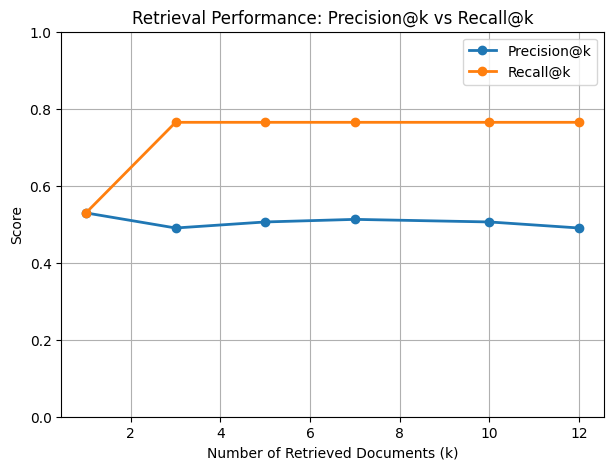

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(ks, precisions, marker='o', linewidth=2, label="Precision@k")
plt.plot(ks, recalls, marker='o', linewidth=2, label="Recall@k")

plt.xlabel("Number of Retrieved Documents (k)")
plt.ylabel("Score")
plt.title("Retrieval Performance: Precision@k vs Recall@k")

plt.ylim(0, 1)
plt.legend()
plt.grid()

plt.show()

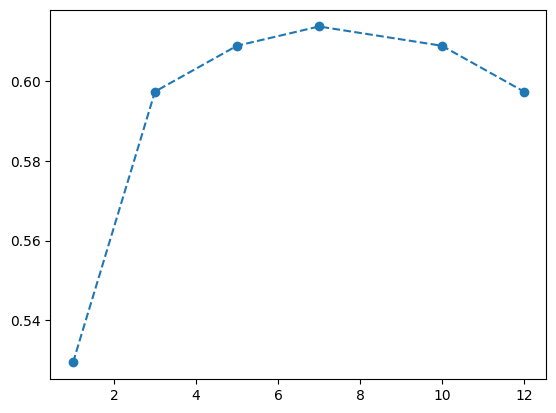

In [ ]:
f1_scores = [
    2*(p*r)/(p+r) if (p+r) > 0 else 0
    for p, r in zip(precisions, recalls)
]

plt.plot(ks, f1_scores, marker='o', linestyle='--', label="F1@k")

In [ ]:
def compute_mrr(df_gold, vector_db, k=5):
    import numpy as np
    import os

    reciprocal_ranks = []

    for _, row in df_gold.iterrows():
        query = row["Question"]
        gold = row["Gold Source"]

        results = vector_db.max_marginal_relevance_search(
            query,
            k=k,
            fetch_k=20
        )

        retrieved_sources = [
            os.path.basename(doc.metadata.get("source", ""))
            for doc in results
        ]

        rank = 0
        for i, s in enumerate(retrieved_sources):
            if s == gold:
                rank = i + 1
                break

        if rank > 0:
            reciprocal_ranks.append(1 / rank)
        else:
            reciprocal_ranks.append(0)

    return np.mean(reciprocal_ranks)

In [ ]:
mrr = compute_mrr(df_gold, vector_db, k=5)
print(f"MRR: {mrr:.4f}")

MRR: 0.5794


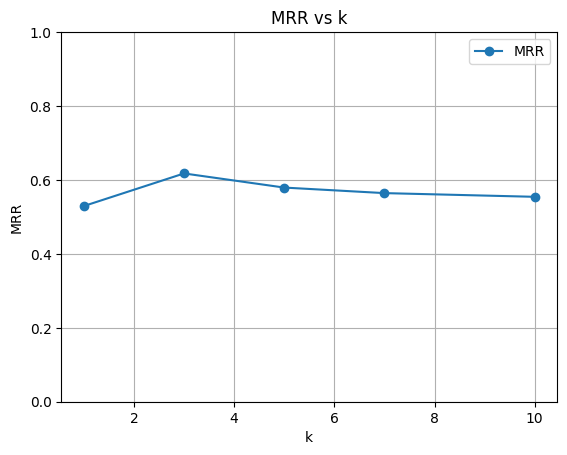

In [ ]:
ks = [1, 3, 5, 7, 10]
mrr_scores = []

for k in ks:
    mrr = compute_mrr(df_gold, vector_db, k)
    mrr_scores.append(mrr)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(ks, mrr_scores, marker='o', label="MRR")

plt.xlabel("k")
plt.ylabel("MRR")
plt.title("MRR vs k")

plt.ylim(0, 1)
plt.grid()
plt.legend()

plt.show()

- k=3 actually captures the majority of what the retriever can offer
- improving generation quality likely requires either better chunking, a larger k for harder questions, or expanding the document base
